In [108]:
import pandas as pd

In [109]:
path = "../data/df_model.csv"

df = pd.read_csv(path, low_memory=False)

df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,severity,total_visits,diag_1g,diag_2g,diag_3g
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Other,...,No,No,No,No,0,2,0,diabetes,na,na
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,NaN,...,No,No,Ch,Yes,0,30,0,other,diabetes,other
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,...,No,No,No,Yes,0,14,3,other,diabetes,other
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,NaN,...,No,No,Ch,Yes,0,16,0,other,diabetes,circulatory
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,NaN,...,No,No,Ch,Yes,0,6,0,neoplasms,neoplasms,diabetes


## Splitting Data

In [110]:
from sklearn.model_selection import train_test_split

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=631, stratify=y)

## Transforming

In [111]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler

from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVR
from sklearn.feature_selection import VarianceThreshold

In [112]:
num_attribs = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_attribs = X.select_dtypes(include='object').columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
])

# with svm selector
# svm_selector = SelectFromModel(
#     LinearSVR(C=0.01, random_state=631, max_iter=10000),
#     threshold="median"
# )

# full_pipeline = Pipeline([
#     ("preprocessing", preprocessor),
#     ("feature_selection", svm_selector),
# ])

In [113]:
X_train_prepared = full_pipeline.fit_transform(X_train, y_train)
X_test_prepared = full_pipeline.transform(X_test)

# undersampling for model comparison / feature selection
rus = RandomUnderSampler(replacement=False)
X_train_prepared, y_train = rus.fit_resample(X_train_prepared, y_train)

# variance threshold
# selector = VarianceThreshold(threshold=0.01)

# X_train_selected = selector.fit_transform(X_train_prepared)
# X_test_selected = selector.transform(X_test_prepared)

Baseline model for feature selection

In [114]:
from sklearn.linear_model import LogisticRegression
import numpy as np

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_prepared, y_train)

feature_names = full_pipeline.get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(model.coef_[0])
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print("\nImportant Features:\n")
print(importance.head(20))


Important Features:

                                               Feature  Importance
23                                     cat__age_[0-10)    0.828644
63                              cat__chlorpropamide_No    0.777304
64                          cat__chlorpropamide_Steady    0.763135
86                             cat__rosiglitazone_Down    0.621761
48             cat__medical_specialty_Surgery-Vascular    0.492017
24                                    cat__age_[10-20)    0.487877
41   cat__medical_specialty_Orthopedics-Reconstructive    0.428268
54                               cat__repaglinide_Down    0.422614
96                                cat__miglitol_Steady    0.364267
39      cat__medical_specialty_ObstetricsandGynecology    0.344819
72                                 cat__glipizide_Down    0.336651
68                             cat__glimepiride_Steady    0.320795
87                               cat__rosiglitazone_No    0.316914
33                   cat__medical_specia

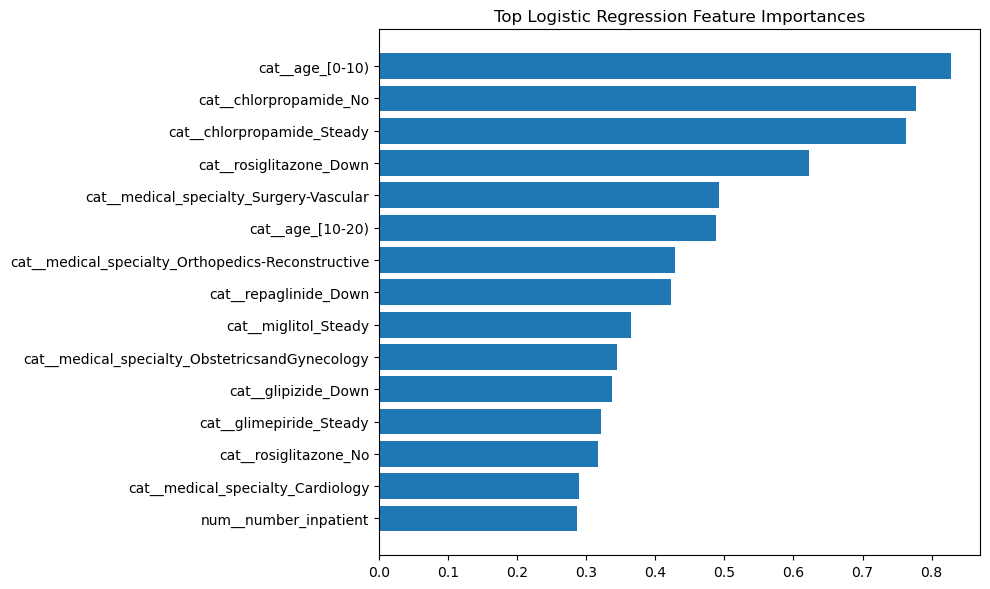

In [115]:
top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.gca().invert_yaxis()

plt.title("Top Logistic Regression Feature Importances")
plt.tight_layout()
plt.show()

## Models